<a href="https://colab.research.google.com/github/magnogomes874/SSD-/blob/main/MVP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MVP — Planejamento de uma nova unidade em nuvem**

# **Magno Gomes Sousa - 200031031**


Comparamos custo, prazo e risco de três cenários usando a Multi-Cloud Resource Dataset.


**1. Bibliotecas e importação**

Envie um CSV ou ZIP contendo um único CSV.

In [ ]:
import io
import math
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from google.colab import files

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 3)
plt.rcParams.update({"figure.figsize": (10, 5), "font.size": 11})
print("Tudo pronto para começar!")


Tudo pronto para começar!


In [ ]:
print("Selecione o arquivo baixado do Kaggle:")
uploaded = files.upload()
if len(uploaded) != 1:
    raise ValueError("Envie somente um CSV ou ZIP.")
nome_arquivo, conteudo = next(iter(uploaded.items()))
if nome_arquivo.lower().endswith(".zip"):
    with zipfile.ZipFile(io.BytesIO(conteudo)) as z:
        csvs = [p for p in z.namelist() if p.lower().endswith(".csv")
                and not p.startswith("__MACOSX/")]
        if len(csvs) != 1:
            raise ValueError(f"Selecione um único CSV. Encontrados: {csvs}")
        print("CSV encontrado:", csvs[0])
        conteudo = z.read(csvs[0])
elif not nome_arquivo.lower().endswith(".csv"):
    raise ValueError("O arquivo deve ser CSV ou ZIP.")
try:
    df_original = pd.read_csv(io.BytesIO(conteudo), dtype="string", encoding="utf-8-sig")
except UnicodeDecodeError:
    df_original = pd.read_csv(io.BytesIO(conteudo), dtype="string", encoding="latin1")
print(f"Base carregada: {len(df_original)} registros e {len(df_original.columns)} colunas.")
display(df_original.head())


Selecione o arquivo baixado do Kaggle:


Saving archive (1).zip to archive (1) (1).zip
CSV encontrado: Cloud_Dataset.csv
Base carregada: 1000 registros e 16 colunas.


,timestamp,cpu_usage,memory_usage,net_io,disk_io,cloud_provider,region,vm_type,vCPU,RAM_GB,price_per_hour,target,latency_ms,throughput,cost,utilization
0,2024-01-01 00:00:00,43.71,95.56,379.4,638.79,Azure,us-east,t2.micro,1,1.0,0.0116,scale_up,228.02,1380.99,0.0174,69.64
1,2024-01-01 00:05:00,15.23,87.96,320.5,737.27,Azure,us-west,t2.micro,1,1.0,0.0116,scale_up,243.71,1059.03,0.0174,51.59
2,2024-01-01 00:10:00,26.36,26.51,186.91,572.28,AWS,us-east,B1s,1,1.0,0.012,scale_down,256.32,500.59,0.018,26.44
3,2024-01-01 00:15:00,65.07,22.55,181.47,429.73,AWS,asia-south,B1s,1,1.0,0.012,no_action,270.85,864.91,0.018,43.81
4,2024-01-01 00:20:00,27.97,56.28,316.59,141.81,Azure,us-east,B1s,1,1.0,0.012,no_action,246.37,861.28,0.018,42.12


**2. Limpeza da base**

Preserva o original, padroniza campos e valida números, datas e percentuais. Separa registros inválidos para revisão.


In [ ]:
import re
import unicodedata
import numpy as np
import pandas as pd

def limpar_base(base_original):
    """Retorna base limpa, registros separados, resumo e relatório por coluna.
    Não modifica o DataFrame original e não inventa valores ausentes.
    """
    df = base_original.copy(deep=True)
    if not df.columns.is_unique:
        raise ValueError("O arquivo possui nomes de colunas repetidos.")
    nomes = [re.sub(r"[^a-z0-9]+", "_", unicodedata.normalize("NFKD", str(c))
             .encode("ascii", "ignore").decode().strip().lower()).strip("_")
             for c in df.columns]
    if len(set(nomes)) != len(nomes):
        raise ValueError("A padronização produz nomes repetidos. Revise o cabeçalho.")
    df.columns = nomes
    numericas = ["cpu_usage", "memory_usage", "net_io", "disk_io", "vcpu",
                 "ram_gb", "price_per_hour", "latency_ms", "throughput",
                 "cost", "utilization"]
    textuais = ["cloud_provider", "region", "vm_type", "target"]
    obrigatorias = ["timestamp"] + numericas + textuais
    faltantes = sorted(set(obrigatorias) - set(df.columns))
    if faltantes:
        raise ValueError(f"Colunas ausentes: {faltantes}. Use o CSV Multi-Cloud.")
    # Índice corresponde ao número do registro no arquivo, começando em 1.
    df.index = pd.RangeIndex(1, len(df) + 1, name="registro_origem")
    for c in df.select_dtypes(include=["object", "string"]).columns:
        df[c] = df[c].astype("string").str.strip().replace("", pd.NA)
    motivos = pd.Series("", index=df.index, dtype="string")
    def sinalizar(mascara, motivo):
        mascara = pd.Series(mascara, index=df.index).fillna(False)
        motivos.loc[mascara] = motivos.loc[mascara] + motivo + "; "
    vazias = df.isna().all(axis=1)
    sinalizar(vazias, "Linha totalmente vazia")
    duplicadas = df.duplicated(keep="first") & ~vazias
    sinalizar(duplicadas, "Registro duplicado após remoção de espaços")
    antes = df.isna().sum()
    falhas = {}
    for c in numericas:
        original = df[c].copy()
        df[c] = pd.to_numeric(df[c], errors="coerce")
        falhas[c] = int((original.notna() & df[c].isna()).sum())
        sinalizar(original.notna() & df[c].isna(), f"Número inválido em {c}")
        infinito = df[c].notna() & ~np.isfinite(df[c].astype(float))
        sinalizar(infinito, f"Número infinito em {c}")
        df.loc[infinito, c] = np.nan
    original = df["timestamp"].copy()
    df["timestamp"] = pd.to_datetime(original, format="%Y-%m-%d %H:%M:%S", errors="coerce")
    falhas["timestamp"] = int((original.notna() & df.timestamp.isna()).sum())
    sinalizar(original.notna() & df.timestamp.isna(), "Data inválida")
    df["cloud_provider"] = df.cloud_provider.str.casefold().replace(
        {"aws": "AWS", "azure": "Azure", "gcp": "GCP"})
    for c in ["region", "vm_type", "target"]:
        df[c] = df[c].str.lower()
    for c in obrigatorias:
        sinalizar(df[c].isna() & ~vazias, f"Campo ausente: {c}")
    for c in ["cpu_usage", "memory_usage", "utilization"]:
        sinalizar(df[c].notna() & ~df[c].between(0, 100), f"Percentual fora de 0–100: {c}")
    for c in ["net_io", "disk_io", "price_per_hour", "latency_ms", "throughput", "cost"]:
        sinalizar(df[c] < 0, f"Valor negativo: {c}")
    for c in ["vcpu", "ram_gb"]:
        sinalizar(df[c] <= 0, f"Capacidade não positiva: {c}")
    sinalizar(df.vcpu.notna() & (df.vcpu % 1 != 0), "vCPU deve ser inteiro")
    sinalizar(df.cloud_provider.notna() & ~df.cloud_provider.isin(["AWS", "Azure", "GCP"]),
              "Provedor não reconhecido nesta base")
    sinalizar(df.target.notna() & ~df.target.isin(["scale_up", "scale_down", "no_action"]),
              "Ação target não reconhecida")
    # Não deduplicar apenas por timestamp: pode haver máquinas diferentes no mesmo instante.
    candidatas = df.loc[motivos.eq("")]
    sinalizar(df.index.isin(candidatas.index[candidatas.duplicated(keep="first")]),
              "Registro duplicado após conversões")
    rejeitadas = df.loc[motivos.ne("")].copy()
    rejeitadas["motivo_revisao"] = motivos.loc[rejeitadas.index].str.rstrip("; ")
    limpa = df.loc[motivos.eq("")].sort_values("timestamp", kind="stable").copy()
    limpa["vcpu"] = limpa.vcpu.astype("Int64")
    resumo = pd.DataFrame({"Indicador": ["Registros originais", "Linhas totalmente vazias",
        "Duplicados após ajuste de espaços", "Registros separados para revisão",
        "Registros disponíveis para análise", "Campos ausentes antes das conversões"],
        "Quantidade": [len(base_original), int(vazias.sum()), int(duplicadas.sum()),
                       len(rejeitadas), len(limpa), int(antes.sum())]})
    qualidade = pd.DataFrame({"ausentes_antes_conversao": antes,
        "ausentes_apos_conversao": df.isna().sum(),
        "falhas_conversao": pd.Series(falhas)}).fillna(0).astype(int)
    return limpa, rejeitadas, resumo, qualidade


In [ ]:
import ipywidgets as widgets

botao_limpar = widgets.Button(description="Limpar base", button_style="success", icon="check")
saida_limpeza = widgets.Output()

def executar_limpeza(_=None):
    global df, df_limpo, registros_revisao, resumo_limpeza, qualidade_colunas
    with saida_limpeza:
        saida_limpeza.clear_output()
        df_limpo, registros_revisao, resumo_limpeza, qualidade_colunas = limpar_base(df_original)
        df = df_limpo.copy(deep=True)
        display(resumo_limpeza)
        display(qualidade_colunas)
        if not registros_revisao.empty:
            print("Registros separados para revisão:")
            display(registros_revisao.head(10))
        if df.empty:
            raise ValueError("Nenhum registro válido. Revise o arquivo antes de continuar.")
        print("Base limpa disponível em df. A base original foi preservada.")

botao_limpar.on_click(executar_limpeza)
display(botao_limpar, saida_limpeza)
executar_limpeza()


Button(button_style='success', description='Limpar base', icon='check', style=ButtonStyle())

Output()

**3. Visão geral dos dados**

Resumimos utilização, latência e preços. Cada linha é uma observação, não uma máquina ou cobrança independente. RAM_GB é memória; disk_io não é capacidade de armazenamento. As unidades de I/O e a fórmula de cost precisam de confirmação.

In [ ]:
print("Registros válidos:", len(df))
print("Período:", df.timestamp.min(), "até", df.timestamp.max())
visao_provedores = df.groupby("cloud_provider").agg(
    registros=("timestamp", "size"), cpu_media=("cpu_usage", "mean"),
    memoria_media=("memory_usage", "mean"), latencia_media_ms=("latency_ms", "mean"),
    preco_medio_hora=("price_per_hour", "mean"))
display(visao_provedores)
custos_base = df.groupby("vm_type").agg(
    registros=("timestamp", "size"), preco_medio_hora=("price_per_hour", "mean"),
    preco_minimo_hora=("price_per_hour", "min"), preco_maximo_hora=("price_per_hour", "max"),
    custo_informado_medio=("cost", "mean"))
display(custos_base)


Registros válidos: 1000
Período: 2024-01-01 00:00:00 até 2024-01-04 11:15:00


,registros,cpu_media,memoria_media,latencia_media_ms,preco_medio_hora
cloud_provider,,,,,
AWS,323,54.987,56.636,243.846,0.025
Azure,326,52.555,53.103,247.723,0.023
GCP,351,53.582,53.833,246.256,0.024


,registros,preco_medio_hora,preco_minimo_hora,preco_maximo_hora,custo_informado_medio
vm_type,,,,,
b1s,351,0.012,0.012,0.012,0.018
n1-standard-1,340,0.047,0.048,0.048,0.137
t2.micro,309,0.012,0.012,0.012,0.017


**4. Alertas operacionais**

CPU/memória acima de 80% ou latência acima de 250 ms. A proporção de observações com alerta representa exposição operacional, não probabilidade de falha. A latência não mede o prazo de abertura.

In [ ]:
limite_cpu = 80.0
limite_memoria = 80.0
limite_latencia_ms = 250.0

df["alerta_cpu"] = df.cpu_usage > limite_cpu
df["alerta_memoria"] = df["memory_usage"] > limite_memoria
df["alerta_latencia"] = df.latency_ms > limite_latencia_ms
df["alerta_operacional"] = df[["alerta_cpu", "alerta_memoria", "alerta_latencia"]].any(axis=1)
alertas = pd.DataFrame({"Indicador": ["CPU acima do limite", "Memória acima do limite",
    "Latência acima do limite", "Pelo menos um alerta"],
    "Percentual_observacoes": [100*df[c].mean() for c in
     ["alerta_cpu", "alerta_memoria", "alerta_latencia", "alerta_operacional"]]})
display(alertas)
lista_atencao = df.loc[df.alerta_operacional].sort_values(
    ["cpu_usage", "memory_usage"], ascending=False).head(15)
display(lista_atencao[["timestamp", "cloud_provider", "vm_type", "cpu_usage",
                       "memory_usage", "latency_ms", "target"]])


,Indicador,Percentual_observacoes
0,CPU acima do limite,20.8
1,Memória acima do limite,22.0
2,Latência acima do limite,43.3
3,Pelo menos um alerta,76.6


,timestamp,cloud_provider,vm_type,cpu_usage,memory_usage,latency_ms,target
registro_origem,,,,,,,
223,2024-01-01 18:30:00,Azure,b1s,99.95,14.34,246.07,scale_up
297,2024-01-02 00:40:00,Azure,b1s,99.85,93.98,215.3,scale_up
290,2024-01-02 00:05:00,AWS,n1-standard-1,99.67,43.15,230.84,scale_up
894,2024-01-04 02:25:00,GCP,b1s,99.66,52.71,228.03,scale_up
246,2024-01-01 20:25:00,GCP,n1-standard-1,99.47,69.57,208.43,scale_up
433,2024-01-02 12:00:00,GCP,n1-standard-1,99.39,14.04,257.48,scale_up
570,2024-01-02 23:25:00,AWS,b1s,99.11,38.07,215.02,scale_up
675,2024-01-03 08:10:00,GCP,t2.micro,99.06,71.59,224.45,scale_up
367,2024-01-02 06:30:00,GCP,t2.micro,98.92,50.86,220.37,scale_up


**5. Premissas editáveis**

Informe demanda, orçamento e prazos. Armazenamento e quantidade de máquinas não constam na base. Valide tarifas e combinações de máquina/fornecedor antes de uma aplicação real.
A capacidade lógica é comparada à demanda com margem. O custo de armazenamento inclui todas as cópias. O preço médio de computação reflete a frequência dos registros da amostra.

In [ ]:
#@title Premissas editáveis do projeto
maquinas_referencia = 20 #@param {type:"integer"}
crescimento_demanda_pct = 25 #@param {type:"number"}
armazenamento_demandado_gb = 15000 #@param {type:"number"}
capacidade_referencia_gb = 20000 #@param {type:"number"}
copias_armazenamento = 2 #@param {type:"integer"}
tarifa_armazenamento_gb_mes = 0.02 #@param {type:"number"}
transferencia_demandada_gb_mes = 1000 #@param {type:"number"}
tarifa_transferencia_gb = 0.05 #@param {type:"number"}
horas_operacao_mes = 730 #@param {type:"number"}
custo_implantacao_fixo = 40000 #@param {type:"number"}
custo_configuracao_por_maquina = 100 #@param {type:"number"}
custo_migracao_por_gb = 0.02 #@param {type:"number"}
contingencia_pct = 10 #@param {type:"number"}
custo_equipe_mes = 5000 #@param {type:"number"}
outros_custos_mes = 1000 #@param {type:"number"}
receita_incremental_mes = 12000 #@param {type:"number"}
orcamento_inicial = 65000 #@param {type:"number"}
limite_custo_mensal = 12000 #@param {type:"number"}
limite_payback_anos = 5 #@param {type:"number"}
prazo_desejado_dias = 60 #@param {type:"integer"}
limite_alertas_operacionais_pct = 35 #@param {type:"number"}
margem_armazenamento_pct = 10 #@param {type:"number"}
dias_planejamento = 5 #@param {type:"integer"}
dias_contratacao = 7 #@param {type:"integer"}
dias_seguranca = 10 #@param {type:"integer"}
dias_configuracao_referencia = 8 #@param {type:"integer"}
dias_testes = 7 #@param {type:"integer"}
dias_treinamento = 5 #@param {type:"integer"}
velocidade_migracao_gb_dia = 2000 #@param {type:"number"}

premissas = {k: globals()[k] for k in [
    "maquinas_referencia", "crescimento_demanda_pct", "armazenamento_demandado_gb",
    "capacidade_referencia_gb", "copias_armazenamento", "tarifa_armazenamento_gb_mes",
    "transferencia_demandada_gb_mes", "tarifa_transferencia_gb", "horas_operacao_mes",
    "custo_implantacao_fixo", "custo_configuracao_por_maquina", "custo_migracao_por_gb",
    "contingencia_pct", "custo_equipe_mes", "outros_custos_mes", "receita_incremental_mes",
    "orcamento_inicial", "limite_custo_mensal", "limite_payback_anos", "prazo_desejado_dias",
    "limite_alertas_operacionais_pct", "margem_armazenamento_pct", "dias_planejamento",
    "dias_contratacao", "dias_seguranca", "dias_configuracao_referencia", "dias_testes",
    "dias_treinamento", "velocidade_migracao_gb_dia"]}
for nome, valor in premissas.items():
    if not np.isfinite(valor) or valor < 0:
        raise ValueError(f"Premissa inválida: {nome}. Use um número finito não negativo.")
for nome in ["maquinas_referencia", "capacidade_referencia_gb", "copias_armazenamento",
             "horas_operacao_mes", "velocidade_migracao_gb_dia", "orcamento_inicial",
             "limite_custo_mensal", "prazo_desejado_dias", "limite_payback_anos"]:
    if premissas[nome] <= 0:
        raise ValueError(f"{nome} deve ser maior que zero.")
for nome in ["maquinas_referencia", "copias_armazenamento"]:
    if premissas[nome] % 1 != 0:
        raise ValueError(f"{nome} deve ser inteiro.")
if limite_alertas_operacionais_pct > 100:
    raise ValueError("O limite percentual de alertas deve estar entre 0 e 100.")
if not (0 < limite_cpu <= 100 and 0 < limite_memoria <= 100 and limite_latencia_ms > 0):
    raise ValueError("Revise os limites operacionais da etapa 6.")
display(pd.Series(premissas, name="Valor").rename_axis("Premissa").to_frame())


,Valor
Premissa,
maquinas_referencia,20.00
crescimento_demanda_pct,25.00
armazenamento_demandado_gb,15000.00
capacidade_referencia_gb,20000.00
copias_armazenamento,2.00
tarifa_armazenamento_gb_mes,0.02
transferencia_demandada_gb_mes,1000.00
tarifa_transferencia_gb,0.05
horas_operacao_mes,730.00


**6. Simulação de custo, prazo e retorno**

**- Computação mensal:** preço médio/hora x máquinas x horas/mês.

**- Investimento:** implantação + configuração + migração + contingência.

**- Payback:** investimento ÷ caixa líquido anual (receita menos operação). Sem caixa positivo, não há retorno nesse cenário constante.

**- Cronograma:** contratação e segurança em paralelo; configuração; migração e treinamento em paralelo; testes finais.

CPU e memória são projetadas proporcionalmente ao crescimento e à capacidade. Essa aproximação não é uma previsão treinada. Mantemos a latência observada. O payback não inclui impostos ou desconto temporal.

In [ ]:
def montar_cronograma(fator_capacidade):
    dur_config = math.ceil(dias_configuracao_referencia * fator_capacidade)
    dur_migracao = math.ceil(armazenamento_demandado_gb *
                            (1 + crescimento_demanda_pct / 100) / velocidade_migracao_gb_dia)
    tarefas = [
        ("Planejamento", dias_planejamento, []),
        ("Contratação", dias_contratacao, ["Planejamento"]),
        ("Preparação de segurança", dias_seguranca, ["Planejamento"]),
        ("Configuração", dur_config, ["Contratação", "Preparação de segurança"]),
        ("Migração", dur_migracao, ["Configuração"]),
        ("Treinamento", dias_treinamento, ["Configuração"]),
        ("Testes finais", dias_testes, ["Migração", "Treinamento"])]
    fim = {}
    linhas = []
    for etapa, duracao, dependencias in tarefas:
        inicio = max([fim[d] for d in dependencias], default=0)
        fim[etapa] = inicio + duracao
        linhas.append({"Etapa": etapa, "Inicio_dia": inicio, "Duracao_dias": duracao,
                       "Fim_dia": fim[etapa], "Depende_de": ", ".join(dependencias)})
    return pd.DataFrame(linhas)

def simular_cenario(nome, fator):
    crescimento = 1 + crescimento_demanda_pct / 100
    maquinas = math.ceil(maquinas_referencia * fator)
    fator_real = maquinas / maquinas_referencia
    cpu_projetada = df.cpu_usage * crescimento / fator_real
    memoria_projetada = df["memory_usage"] * crescimento / fator_real
    alertas = (cpu_projetada > limite_cpu) | (memoria_projetada > limite_memoria) | (df.latency_ms > limite_latencia_ms)
    capacidade_gb = capacidade_referencia_gb * fator
    demanda_gb = armazenamento_demandado_gb * crescimento
    armazenamento_necessario = demanda_gb * (1 + margem_armazenamento_pct / 100)
    computacao = df.price_per_hour.mean() * maquinas * horas_operacao_mes
    armazenamento = capacidade_gb * copias_armazenamento * tarifa_armazenamento_gb_mes
    transferencia = transferencia_demandada_gb_mes * crescimento * tarifa_transferencia_gb
    operacional = computacao + armazenamento + transferencia + custo_equipe_mes + outros_custos_mes
    investimento_base = custo_implantacao_fixo + maquinas*custo_configuracao_por_maquina + demanda_gb*custo_migracao_por_gb
    investimento = investimento_base * (1 + contingencia_pct / 100)
    caixa_anual = (receita_incremental_mes - operacional) * 12
    payback = investimento / caixa_anual if caixa_anual > 0 else np.inf
    cronograma = montar_cronograma(fator_real)
    return {"Cenario": nome, "Fator_capacidade": fator_real, "Maquinas": maquinas,
        "Capacidade_logica_GB": capacidade_gb, "Demanda_projetada_GB": demanda_gb,
        "Capacidade_necessaria_com_margem_GB": armazenamento_necessario,
        "Computacao_mes_UM": computacao, "Armazenamento_mes_UM": armazenamento,
        "Transferencia_mes_UM": transferencia, "Equipe_mes_UM": custo_equipe_mes,
        "Outros_mes_UM": outros_custos_mes, "Custo_mensal_UM": operacional,
        "Investimento_UM": investimento, "Caixa_liquido_anual_UM": caixa_anual,
        "Payback_anos": payback, "Prazo_dias": cronograma.Fim_dia.max(),
        "CPU_p95_projetada_pct": cpu_projetada.quantile(.95),
        "Memoria_p95_projetada_pct": memoria_projetada.quantile(.95),
        "Alertas_operacionais_pct": 100*alertas.mean(),
        "CPU_acima_100_pct": 100*(cpu_projetada > 100).mean(),
        "Memoria_acima_100_pct": 100*(memoria_projetada > 100).mean(),
        "Latencia_acima_limite_pct": 100*(df.latency_ms > limite_latencia_ms).mean()}

cenarios = pd.DataFrame([simular_cenario("Enxuto", 1.0),
    simular_cenario("Intermediário", 1.5), simular_cenario("Ampliado", 2.0)])


In [ ]:
cenarios["Excesso_orcamento_UM"] = (cenarios.Investimento_UM - orcamento_inicial).clip(lower=0)
cenarios["Atraso_dias"] = (cenarios.Prazo_dias - prazo_desejado_dias).clip(lower=0)
cenarios["Deficit_armazenamento_GB"] = (
    cenarios.Capacidade_necessaria_com_margem_GB - cenarios.Capacidade_logica_GB).clip(lower=0)


**7. Recomendação**

**IMPLEMENTAR:** atende a orçamento, custo mensal, prazo, armazenamento, exposição e payback, com caixa positivo.

**REVISAR:** caixa positivo, mas algum limite não é atendido. NÃO IMPLEMENTAR: caixa anual nulo ou negativo.

Entre os aprovados, selecionamos o menor custo total em 12 meses. Sem aprovação, mostramos o cenário com menos restrições descumpridas para orientar a revisão.

In [ ]:
def avaliar(linha):
    motivos = []
    if linha.Investimento_UM > orcamento_inicial: motivos.append("Investimento acima do orçamento")
    if linha.Custo_mensal_UM > limite_custo_mensal: motivos.append("Custo mensal acima do limite")
    if linha.Prazo_dias > prazo_desejado_dias: motivos.append("Prazo superior ao desejado")
    if linha.Deficit_armazenamento_GB > 0: motivos.append("Armazenamento insuficiente com margem")
    if linha.Alertas_operacionais_pct > limite_alertas_operacionais_pct:
        motivos.append("Exposição operacional acima do limite")
    if linha.Caixa_liquido_anual_UM <= 0:
        motivos.append("Caixa incremental não positivo")
        recomendacao = "NÃO IMPLEMENTAR"
    else:
        if linha.Payback_anos > limite_payback_anos: motivos.append("Payback acima do limite")
        recomendacao = "REVISAR PROJETO" if motivos else "IMPLEMENTAR"
    return pd.Series({"Recomendacao": recomendacao, "Restricoes_descumpridas": len(motivos),
                      "Motivos": "; ".join(motivos) if motivos else "Todos os critérios atendidos"})

cenarios = cenarios.drop(columns=["Recomendacao", "Restricoes_descumpridas", "Motivos"], errors="ignore")
cenarios = pd.concat([cenarios, cenarios.apply(avaliar, axis=1)], axis=1)
cenarios["Custo_total_12_meses_UM"] = cenarios.Investimento_UM + 12*cenarios.Custo_mensal_UM
aprovados = cenarios[cenarios.Recomendacao.eq("IMPLEMENTAR")]
if not aprovados.empty:
    selecionado = aprovados.sort_values("Custo_total_12_meses_UM").iloc[0]
    print("Cenário indicado entre os aprovados:", selecionado.Cenario)
else:
    selecionado = cenarios.sort_values(["Restricoes_descumpridas", "Custo_total_12_meses_UM"]).iloc[0]
    print("Nenhum cenário aprovado. Cenário de referência para revisar:", selecionado.Cenario)
display(cenarios[["Cenario", "Recomendacao", "Motivos", "Custo_total_12_meses_UM"]])
print("Resultado:", selecionado.Recomendacao)
print("Justificativa:", selecionado.Motivos)


Nenhum cenário aprovado. Cenário de referência para revisar: Intermediário


,Cenario,Recomendacao,Motivos,Custo_total_12_meses_UM
0,Enxuto,REVISAR PROJETO,Armazenamento insuficiente com margem; Exposiç...,133157.909
1,Intermediário,REVISAR PROJETO,Exposição operacional acima do limite,141155.614
2,Ampliado,REVISAR PROJETO,Exposição operacional acima do limite,149153.319


Resultado: REVISAR PROJETO
Justificativa: Exposição operacional acima do limite


**8. Painel e cronograma**

O cronograma mostra as dependências entre atividades





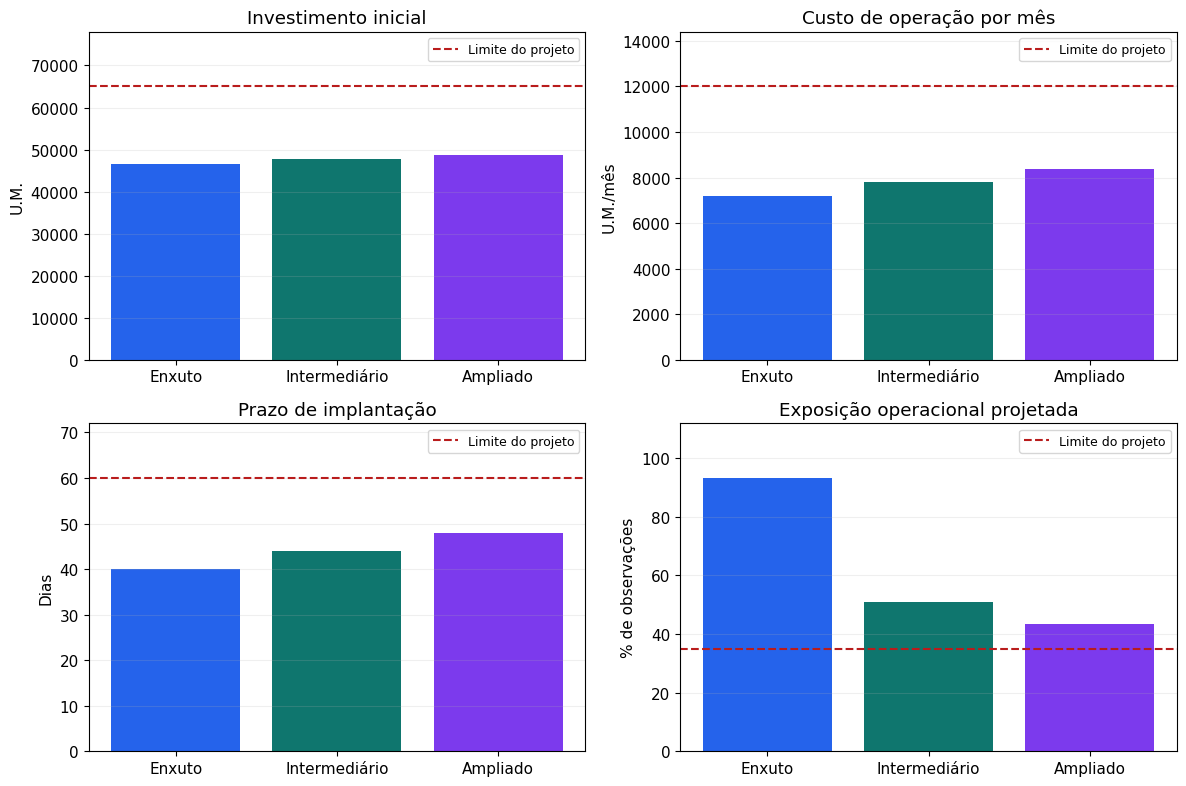

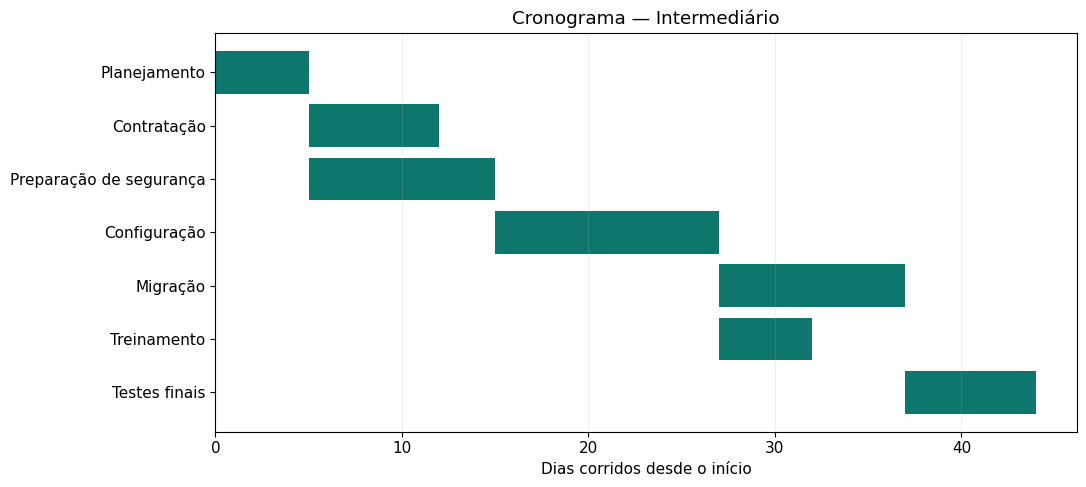

,Etapa,Inicio_dia,Duracao_dias,Fim_dia,Depende_de
0,Planejamento,0,5,5,
1,Contratação,5,7,12,Planejamento
2,Preparação de segurança,5,10,15,Planejamento
3,Configuração,15,12,27,"Contratação, Preparação de segurança"
4,Migração,27,10,37,Configuração
5,Treinamento,27,5,32,Configuração
6,Testes finais,37,7,44,"Migração, Treinamento"


Investimento: 47,712.50 U.M.
Custo mensal: 7,786.93 U.M.
Prazo: 44 dias
Payback: 0.94 anos
Recomendação: REVISAR PROJETO


In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
cor = ["#2563eb", "#0f766e", "#7c3aed"]
for ax, coluna, titulo, unidade, limite in [
    (axs[0,0], "Investimento_UM", "Investimento inicial", "U.M.", orcamento_inicial),
    (axs[0,1], "Custo_mensal_UM", "Custo de operação por mês", "U.M./mês", limite_custo_mensal),
    (axs[1,0], "Prazo_dias", "Prazo de implantação", "Dias", prazo_desejado_dias),
    (axs[1,1], "Alertas_operacionais_pct", "Exposição operacional projetada", "% de observações", limite_alertas_operacionais_pct)]:
    ax.bar(cenarios.Cenario, cenarios[coluna], color=cor)
    ax.axhline(limite, color="#b91c1c", linestyle="--", label="Limite do projeto")
    ax.set(title=titulo, ylabel=unidade)
    ax.set_ylim(0, max(float(cenarios[coluna].max()), limite, 1)*1.2)
    ax.grid(axis="y", alpha=.2)
    ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

cronograma = montar_cronograma(float(selecionado.Fator_capacidade))
fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(cronograma.Etapa, cronograma.Duracao_dias, left=cronograma.Inicio_dia, color="#0f766e")
ax.invert_yaxis()
ax.set(title=f"Cronograma — {selecionado.Cenario}", xlabel="Dias corridos desde o início")
ax.grid(axis="x", alpha=.2)
fig.tight_layout()
plt.show()
display(cronograma)
print(f"Investimento: {selecionado.Investimento_UM:,.2f} U.M.")
print(f"Custo mensal: {selecionado.Custo_mensal_UM:,.2f} U.M.")
print(f"Prazo: {selecionado.Prazo_dias:.0f} dias")
print(f"Payback: {selecionado.Payback_anos:.2f} anos")
print("Recomendação:", selecionado.Recomendacao)


**9. Planejar a abertura**

Confirmar demanda e tarifas; aprovar cenário e orçamento; contratar e preparar segurança; configurar; migrar em piloto; testar acesso, integridade, desempenho e restauração; iniciar a operação após aprovação dos testes.
Se a latência permanecer acima do limite, investigar rede e região: ampliar máquinas, por si só, não garante menor latência.

**10. Conclusão**

Conseguimos comparar os custos, prazos e os riscos operacionais para planejar uma nova unidade de armazenamento em nuvem.

Com as premissas atuais, a recomendação é **REVISAR O PROJETO**, pois os três cenários apresentam exposição operacional acima do limite definido. O cenário intermediário foi selecionado como referência para a revisão.
